In [16]:
import pandas as pd
import numpy as np

data=pd.read_csv("restaurant_pattern_dataset.csv")
data

,date,day_of_week,temperature,weather,event,is_weekend,menu_item,price,promotion,predicted_sales,production,actual_sales,wastage
0,2024-01-01,Monday,38.5,Rainy,NaN,0,Biryani,220,0,123,137,135,2
1,2024-01-01,Monday,38.5,Rainy,NaN,0,Fried_Rice,180,0,87,97,84,13
2,2024-01-01,Monday,38.5,Rainy,NaN,0,Noodles,160,0,73,81,69,12
3,2024-01-01,Monday,38.5,Rainy,NaN,0,Paneer_Curry,200,0,60,67,63,4
4,2024-01-01,Monday,38.5,Rainy,NaN,0,Chicken_Curry,240,0,108,120,100,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5470,2024-12-30,Monday,25.3,Rainy,NaN,0,Cooldrinks,50,0,98,109,100,9
5471,2024-12-30,Monday,25.3,Rainy,NaN,0,IceCream,90,0,85,95,89,6
5472,2024-12-30,Monday,25.3,Rainy,NaN,0,Puri,70,0,119,133,131,2
5473,2024-12-30,Monday,25.3,Rainy,NaN,0,Tea,20,0,308,344,283,61


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

data.sample(5)

,date,day_of_week,temperature,weather,event,is_weekend,menu_item,price,promotion,predicted_sales,production,actual_sales,wastage
4693,2024-11-08,Friday,31.7,Cloudy,NaN,0,Tea,20,0,174,194,177,17
1461,2024-04-07,Sunday,21.7,Sunny,NaN,1,Parotta,100,0,70,78,76,2
4692,2024-11-08,Friday,31.7,Cloudy,NaN,0,Puri,70,0,112,125,122,3
3375,2024-08-13,Tuesday,33.7,Sunny,NaN,0,Biryani,220,0,154,172,141,31
1394,2024-04-02,Tuesday,33.5,Sunny,NaN,0,Coffee,40,0,134,150,128,22


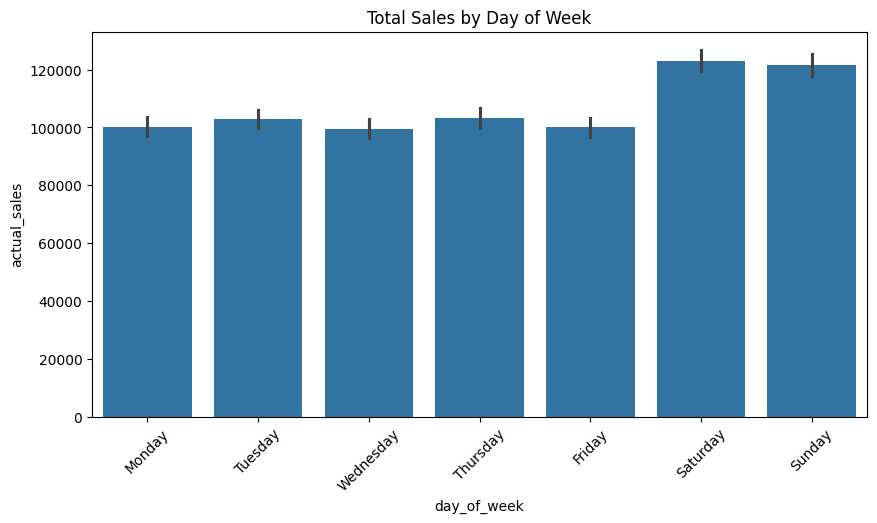

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="day_of_week",
    y="actual_sales",
    data=data,
    estimator=sum
)

plt.title("Total Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

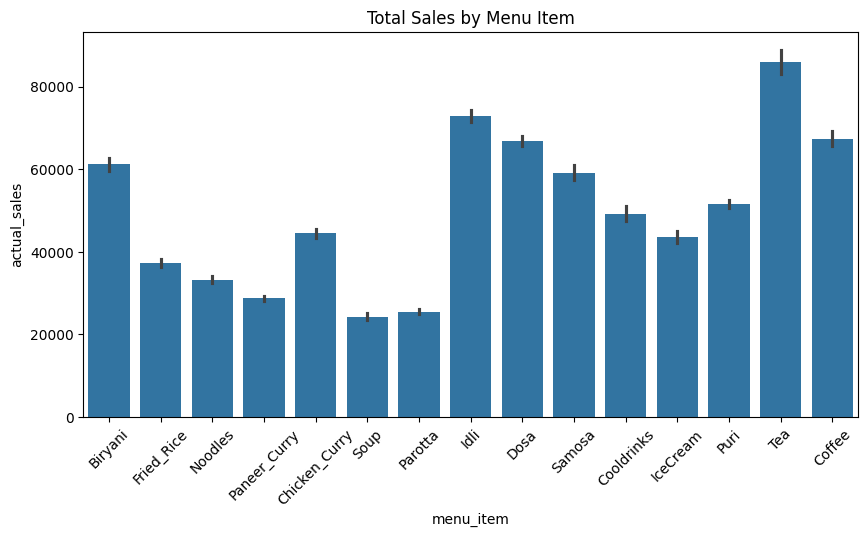

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="menu_item",
    y="actual_sales",
    data=data,
    estimator=sum
)

plt.title("Total Sales by Menu Item")
plt.xticks(rotation=45)
plt.show()


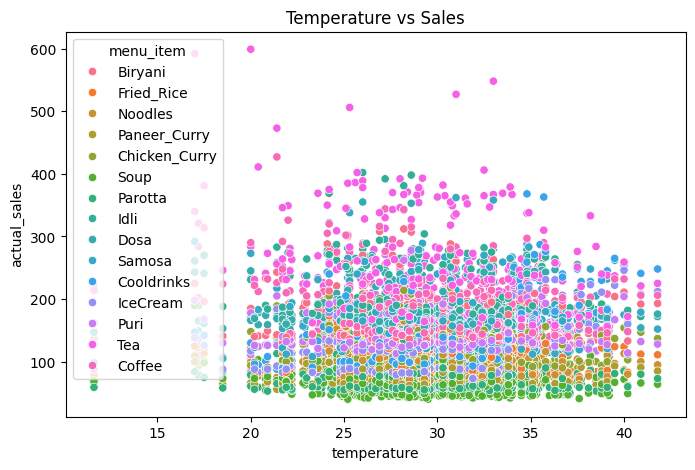

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="temperature",
    y="actual_sales",
    hue="menu_item",
    data=data
)

plt.title("Temperature vs Sales")
plt.show()

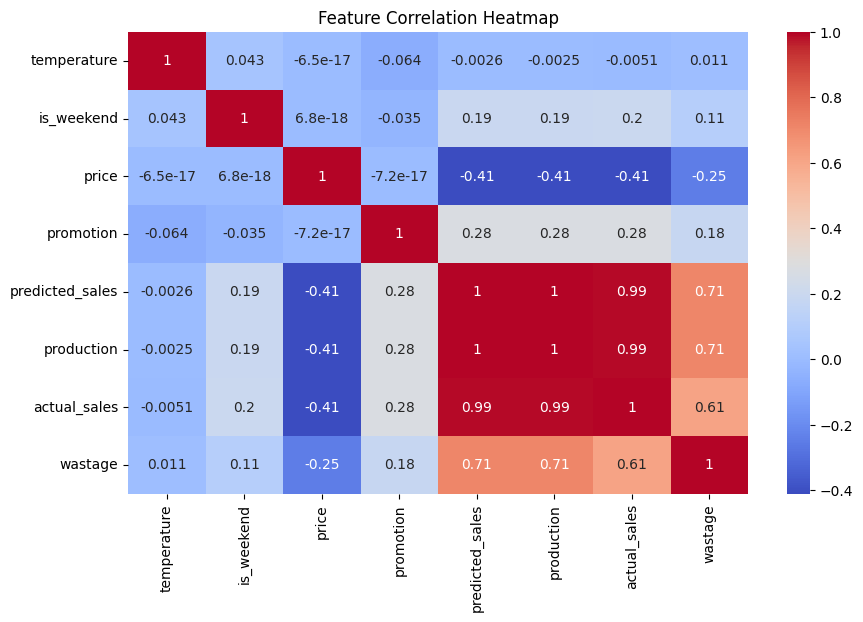

In [22]:
plt.figure(figsize=(10,6))

corr = data.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()


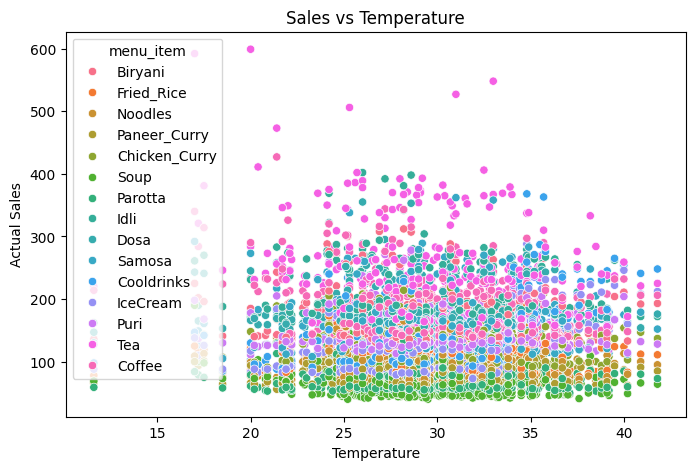

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="temperature",
    y="actual_sales",
    hue="menu_item"
)

plt.title("Sales vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Actual Sales")

plt.show()

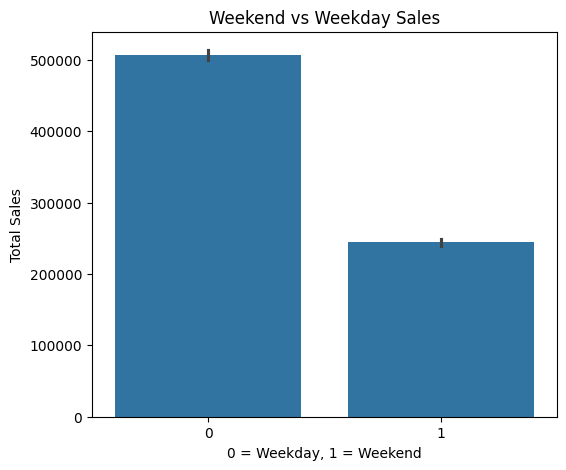

In [26]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=data,
    x="is_weekend",
    y="actual_sales",
    estimator=sum
)

plt.title("Weekend vs Weekday Sales")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Total Sales")

plt.show()

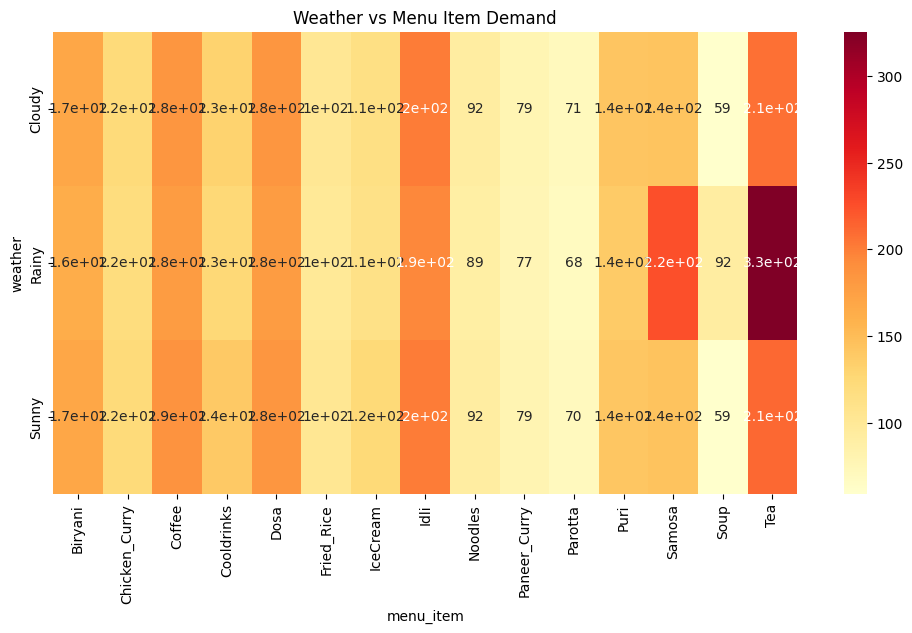

In [28]:
pivot = data.pivot_table(
    values="actual_sales",
    index="weather",
    columns="menu_item",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlOrRd"
)

plt.title("Weather vs Menu Item Demand")

plt.show()

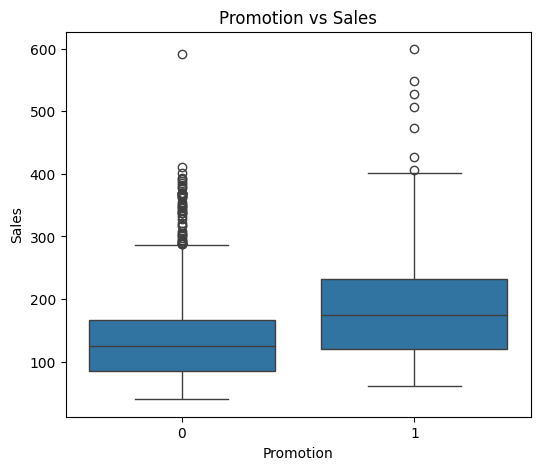

In [30]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=data,
    x="promotion",
    y="actual_sales"
)

plt.title("Promotion vs Sales")
plt.xlabel("Promotion")
plt.ylabel("Sales")

plt.show()

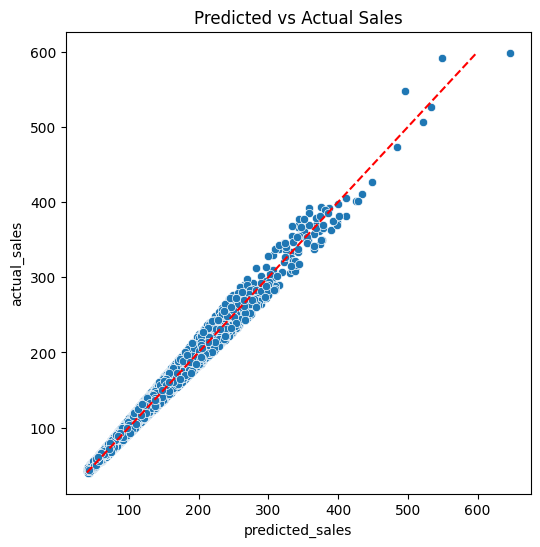

In [33]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    data=data,
    x="predicted_sales",
    y="actual_sales"
)

plt.plot(
    [data.actual_sales.min(), data.actual_sales.max()],
    [data.actual_sales.min(), data.actual_sales.max()],
    'r--'
)

plt.title("Predicted vs Actual Sales")

plt.show()

In [36]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date")

sns.set_style("whitegrid")

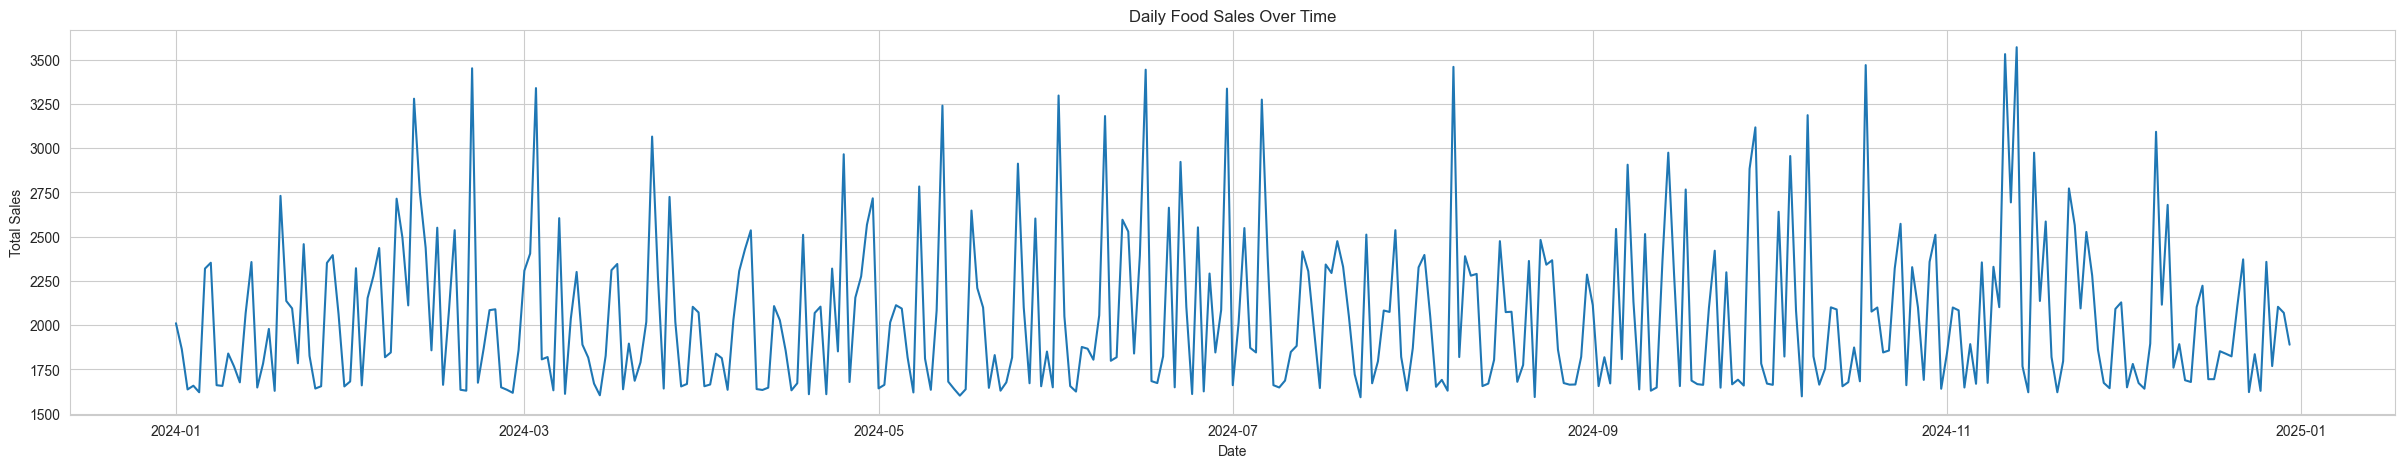

In [40]:
daily_sales = data.groupby("date")["actual_sales"].sum().reset_index()

plt.figure(figsize=(30,5))

sns.lineplot(
    data=daily_sales,
    x="date",
    y="actual_sales"
)

plt.title("Daily Food Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

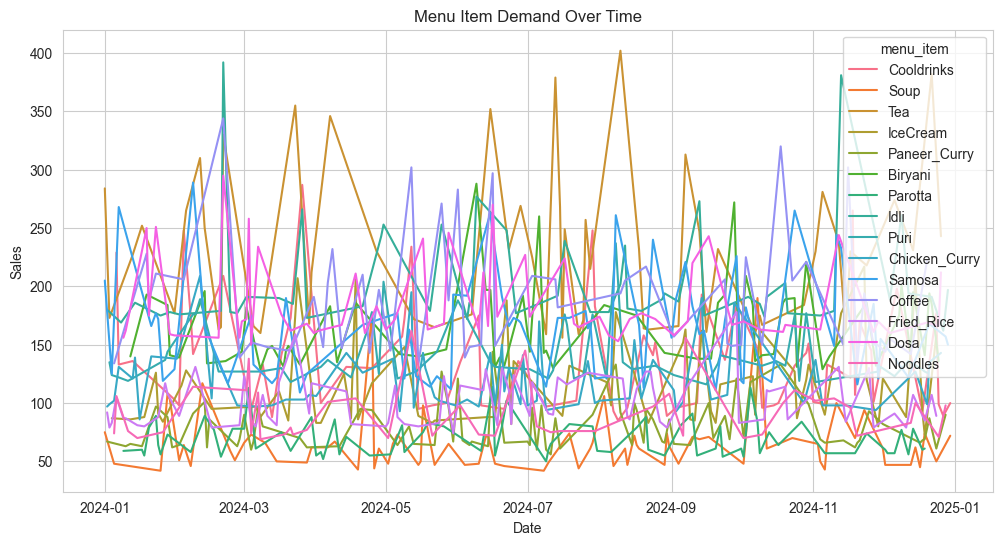

In [48]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=data.sample(1000),
    x="date",
    y="actual_sales",
    hue="menu_item",
    estimator="sum"
)

plt.title("Menu Item Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

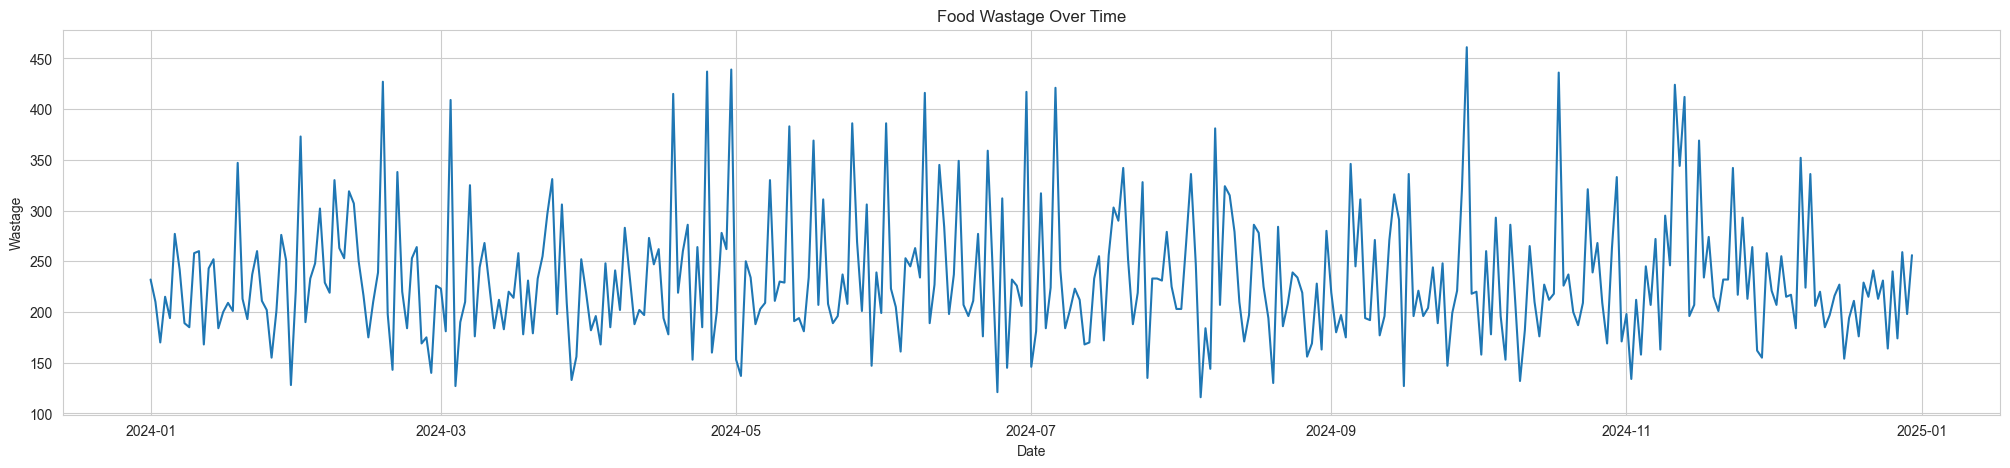

In [50]:
daily_waste = data.groupby("date")["wastage"].sum().reset_index()

plt.figure(figsize=(25,5))

sns.lineplot(
    data=daily_waste,
    x="date",
    y="wastage"
)

plt.title("Food Wastage Over Time")
plt.xlabel("Date")
plt.ylabel("Wastage")

plt.show()

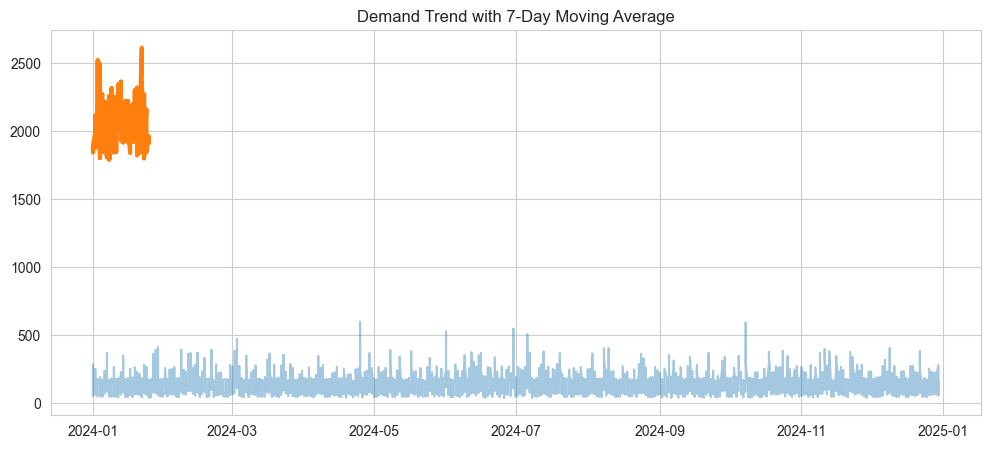

In [51]:
data["rolling_avg"] = daily_sales["actual_sales"].rolling(7).mean()

plt.figure(figsize=(12,5))

plt.plot(data["date"], data["actual_sales"], alpha=0.4)
plt.plot(data["date"], data["rolling_avg"], linewidth=3)

plt.title("Demand Trend with 7-Day Moving Average")

plt.show()